# Lesson 3: demonstration quality with FiftyOne

Episode metadata (`length`, `duration`, `task`) says nothing about *how good* a demonstration is: whether the operator hesitated, moved smoothly, grasped early or late. That information is in the 14-dim action curves. This lesson pulls it out once, stores it on the samples, and uses FiftyOne to sort, tag, compare, and finally export the clean demos.

![the loop: compute, store, query, look, hand off](figures/15_curation_loop.png)

You will be able to:

1. Compute per-episode kinematic features and attach them with `set_values`
2. Mark grasp events on the timeline with **temporal tags** and filter by them
3. Keep useful queries as **saved views**
4. Find similar and outlier demonstrations with FiftyOne Brain on motion embeddings
5. Tag outliers and export the remaining demos as a training-ready LeRobot dataset

Prerequisite: Lesson 2 (the pointer in section 5, the export in section 7). Dataset: `lerobot-aloha-sim-insertion-human`. Env: `fo_lerobot`.

This notebook **writes** to the dataset: six float fields, one embedding field, temporal tags, a saved view, two brain runs, one sample tag. It also writes an export to `./exports/`. Everything is re-runnable; the last cell shows how to undo it.

## 1. Load the dataset and the frame table

Two reads, and it matters which is which.

**FiftyOne** holds one sample per episode: the scalars (`episode_index`, `duration`, ...) and the pointer (`media_reference`). Anything per-episode is a `values()` call away.

**The frames are not in FiftyOne.** The 25 000 rows of `action` and `observation.state` live in the LeRobot parquet on disk, and there is no `sample.frames` for LeRobot episodes. Every feature in this lesson is computed from those rows, so one native read is required: Lesson 2's road 1, `LeRobotDataset(root=dataset.media_sources[0]["loc"])`.

Which rows belong to which episode is FiftyOne's job again: `dataset.values("media_reference.data")` returns every sample's `[chunk, file, row_start, row_end]` in one call. That dict is the only bridge the rest of the notebook needs.

In [1]:
import logging
import os
import shutil
from pathlib import Path

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
logging.getLogger("lerobot").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import numpy as np

import fiftyone as fo
import fiftyone.brain as fob
import fiftyone.core.tags as fota
from fiftyone import ViewField as F
from lerobot.datasets.lerobot_dataset import LeRobotDataset

dataset = fo.load_dataset("lerobot-aloha-sim-insertion-human")

# The frame-level rows are not in FiftyOne. Read them once through the pointer (Lesson 2, road 1).
lr = LeRobotDataset("lerobot/aloha_sim_insertion_human", root=dataset.media_sources[0]["loc"])
table = lr.hf_dataset.with_format("numpy")
A = np.asarray(table["action"])               # (25000, 14) commanded joint positions
S = np.asarray(table["observation.state"])    # (25000, 14) measured joint positions
fps = lr.fps

# Which rows are which episode: every sample's pointer, in one call. {episode_index: [chunk, file, row_start, row_end]}
episode_rows = dict(zip(*dataset.values(["episode_index", "media_reference.data"])))

print("episodes:", len(dataset), "  frame rows:", A.shape, "  fps:", fps)
print("episode 0 rows:", episode_rows[0])

session = fo.launch_app(dataset, auto=False)
print("App:", session.url)

episodes: 50   frame rows: (25000, 14)   fps: 50
episode 0 rows: [0, 0, 0, 500]


Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


App: http://localhost:5151/


## 2. Per-episode kinematics as sample fields

Six features per episode, all from `action` and `observation.state`:

| field | meaning |
|---|---|
| `joint_travel` | total path length of the 12 arm joints (sum of per-step distances). Longer = more wandering |
| `peak_speed` | max per-step joint speed. Spikes = jerky teleop |
| `idle_frac` | fraction of frames where the arms barely move. High = hesitation |
| `track_err` | mean absolute gap between commanded `action` and measured `state` on arm joints. High = controller lagging |
| `grasp_t_left`, `grasp_t_right` | seconds until each gripper closes on its object. Long = slow approach |

![three views of episode 0's curves reduced to six numbers on the sample](figures/12_kinematics.png)

Gripper convention here: **high = open, low = closed**. Each gripper starts closed, opens on the way in, closes on the peg/socket. After the close command (~0.12) the measured state stays near 0.65: the object is in the jaws. That is why `track_err` excludes gripper dims; their command/state gap is the object, not controller lag.

One NumPy pass per episode, slicing `A` and `S` with the row range from the pointer. Results are written with `set_values(field, {episode_index: value}, key_field="episode_index")`: FiftyOne matches each value to its sample by the key, so nothing has to be sorted or aligned by position. After this cell the six fields appear in the App sidebar as range sliders.

In [2]:
ARM = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]  # joints, grippers excluded
L_GRIP, R_GRIP = 6, 13

def grasp_time(g):
    """Seconds until the gripper closes on the object: first drop below the
    midpoint *after* the first rise above it (high = open, low = closed)."""
    mid = (g.max() + g.min()) / 2
    opened = np.where(g > mid)[0]
    if len(opened) == 0:
        return float(len(g) / fps)
    closed = np.where(g[opened[0]:] < mid)[0]
    if len(closed) == 0:
        return float(len(g) / fps)
    return float((opened[0] + closed[0]) / fps)

def episode_features(a, s):
    """Six numbers from one episode's (T, 14) action and state arrays."""
    step = np.linalg.norm(np.diff(a[:, ARM], axis=0), axis=1)      # joint-space distance per step
    return {
        "joint_travel": float(step.sum()),
        "peak_speed": float(step.max() * fps),
        "idle_frac": float((step < 1e-3).mean()),
        "track_err": float(np.abs(a[:, ARM] - s[:, ARM]).mean()),
        "grasp_t_left": grasp_time(a[:, L_GRIP]),
        "grasp_t_right": grasp_time(a[:, R_GRIP]),
    }

# {episode_index: {field: value}}, one slice of the frame table per episode
features = {ep: episode_features(A[r0:r1], S[r0:r1]) for ep, (_, _, r0, r1) in episode_rows.items()}

# One set_values per field, keyed by episode_index. No sorting, no positional alignment.
FIELDS = list(next(iter(features.values())))
for name in FIELDS:
    dataset.set_values(name, {ep: f[name] for ep, f in features.items()}, key_field="episode_index")

print("new fields:", [f for f in dataset.get_field_schema() if f in FIELDS])
aggs = [agg for name in FIELDS for agg in (fo.Bounds(name), fo.Mean(name))]   # one round-trip for all 12 numbers
results = dataset.aggregate(aggs)
for i, name in enumerate(FIELDS):
    (lo, hi), mean = results[2 * i], results[2 * i + 1]
    print(f"{name:14s} min {lo:8.3f}   mean {mean:8.3f}   max {hi:8.3f}")

new fields: ['joint_travel', 'peak_speed', 'idle_frac', 'track_err', 'grasp_t_left', 'grasp_t_right']
joint_travel   min    4.981   mean    6.384   max    8.224
peak_speed     min    3.262   mean    4.846   max    6.911
idle_frac      min    0.000   mean    0.018   max    0.076
track_err      min    0.007   mean    0.010   max    0.015
grasp_t_left   min    1.860   mean    2.450   max    3.540
grasp_t_right  min    3.380   mean    4.342   max    5.820


## 3. Grasp events as temporal tags

`grasp_t_left` is a number in the sidebar. The grasp is an **event at a time inside the episode**, and FiftyOne has a native object for that: a `TemporalTag` is a `[start, end)` interval on one sample, in nanoseconds from the start of the recording. They render on the App's playback timeline, and `match_temporal_tags` filters samples by them.

![a temporal tag is an interval on the episode timeline](figures/13_temporal_tags.png)

Below: a 0.5 s window around each grasp, tagged `left grasp` / `right grasp` on every episode. `add` is idempotent on `(sample, start, end, tag)`, so re-running does not duplicate; we still `delete` first so the windows update if `grasp_time` changes.

In the App you can add your own: Shift + drag on the timeline, type a tag.

In [3]:
NS = 1_000_000_000
HALF_WINDOW_S = 0.25

dataset.temporal_tags.delete(tags=["left grasp", "right grasp"])

tags = []
for sid, tl, tr in zip(*dataset.values(["id", "grasp_t_left", "grasp_t_right"])):   # TemporalTag is keyed by sample id
    for t_grasp, label in [(tl, "left grasp"), (tr, "right grasp")]:
        tags.append(fota.TemporalTag(
            sid,
            start=int(max(0.0, t_grasp - HALF_WINDOW_S) * NS),
            end=int((t_grasp + HALF_WINDOW_S) * NS),
            tag=label,
        ))
dataset.temporal_tags.add(tags)

print("temporal tag counts:", dataset.temporal_tags.count())
print("first tag:", dataset.temporal_tags.first())

# episodes whose right grasp happened after t = 5 s
late_right = dataset.match_temporal_tags(tags="right grasp", start=5 * NS)
print("right grasp after 5 s:", late_right.values("episode_index"))

temporal tag counts: {'left grasp': 50, 'right grasp': 50}
first tag: TemporalTag(sample_id='6aa2f301b3580af005249e74', start=3290000000, end=3790000000, tag='left grasp', index_type=2, anchor=None, created_by=None, last_modified_by=None, created_at=datetime.datetime(2026, 9, 17, 23, 56, 13, 82000), last_modified_at=datetime.datetime(2026, 9, 17, 23, 56, 13, 82000), id='6aac7e1d4dc06f409003a946')
right grasp after 5 s: [0, 1, 4, 6, 11, 18, 24, 26, 28, 32, 47]


## 4. Questions about demo quality are now one-line views

- the 5 most hesitant demos (`idle_frac`)
- the operator's bimanual strategy: `grasp_t_left` is always before `grasp_t_right`, so sort by the gap to find demos where the second grasp lagged
- histograms of `joint_travel`, `track_err`, `grasp_t_left`: do the 50 demos share one strategy or several?

The hesitant-demos query is worth keeping, so it becomes a **saved view**: `dataset.save_view(name, view)` stores the query on the dataset. It shows up in the App's view selector and reloads with `dataset.load_saved_view(name)`.

most hesitant episodes: [(36, np.float64(0.076)), (12, np.float64(0.046)), (10, np.float64(0.044)), (23, np.float64(0.044)), (34, np.float64(0.04))]
saved views: ['hesitant_demos']
largest left->right grasp gap (s): [(24, np.float64(3.38)), (28, np.float64(3.26)), (26, np.float64(3.08)), (11, np.float64(2.74)), (47, np.float64(2.34))]
any demo grasping right before left? []


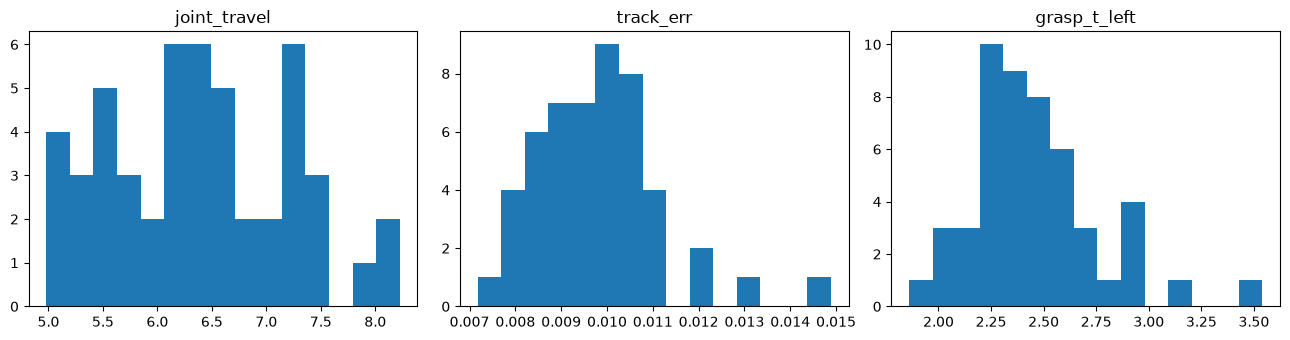

In [4]:
hesitant = dataset.sort_by("idle_frac", reverse=True).limit(5)
eps, idles = hesitant.values(["episode_index", "idle_frac"])
print("most hesitant episodes:", list(zip(eps, np.round(idles, 3))))

if "hesitant_demos" in dataset.list_saved_views():
    dataset.delete_saved_view("hesitant_demos")
dataset.save_view("hesitant_demos", hesitant, description="5 demos with the highest idle_frac")
print("saved views:", dataset.list_saved_views())

slow_second = dataset.sort_by(F("grasp_t_right") - F("grasp_t_left"), reverse=True).limit(5)
eps, t_left, t_right = slow_second.values(["episode_index", "grasp_t_left", "grasp_t_right"])
gaps = np.round(np.array(t_right) - np.array(t_left), 2)
print("largest left->right grasp gap (s):", list(zip(eps, gaps)))
print("any demo grasping right before left?", dataset.match(F("grasp_t_right") < F("grasp_t_left")).values("episode_index"))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, name in zip(axes, ["joint_travel", "track_err", "grasp_t_left"]):
    ax.hist(dataset.values(name), bins=15)
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 5. Which demonstrations are alike? FiftyOne Brain on motion

Brain methods work on **embeddings**: one vector per sample. Usually that vector comes from an image model. Here the thing that distinguishes demos is the *motion*, so the embedding is the motion itself: resample each episode's `(T, 14)` action curve to 25 evenly spaced timesteps and flatten to a 350-dim vector.

![the motion curve is the embedding; similarity and PCA on it](figures/14_motion_embedding.png)

The vector is stored on each sample as a field (`traj_embedding`, via `set_values` keyed by episode), and both Brain runs read it by field name. That keeps the embedding next to the episode it describes and makes the runs re-creatable from the dataset alone. Both are stored on the dataset under a `brain_key`:

- `compute_similarity` → `sort_by_similarity(sample_id)`: "show me the demos most like this one"
- `compute_visualization(method="pca")`: a 2-D map of all 50 demos. Clusters = distinct strategies; isolated points = odd demos. In the App, the Embeddings panel plots this and lassoing points selects episodes.

PCA is the reducer here: no extra packages, deterministic, and adequate for 50 points. For hundreds or thousands of episodes use `method="umap"` (requires `umap-learn`), which preserves local cluster structure better.

traj_embedding: VectorField of length 350


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


episodes most like episode 0 (first is itself): [0, 32, 1, 18, 33, 4]


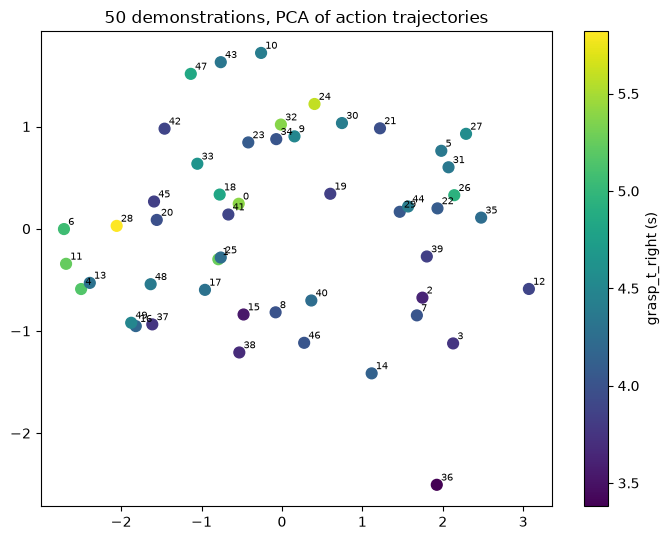

In [5]:
N_STEPS = 25

def motion_vector(a):
    """(T, 14) -> (350,): 25 evenly spaced rows, flattened."""
    idx = np.linspace(0, len(a) - 1, N_STEPS).astype(int)
    return a[idx].ravel()

# The embedding lives on the sample, like any other field
dataset.set_values(
    "traj_embedding",
    {ep: motion_vector(A[r0:r1]) for ep, (_, _, r0, r1) in episode_rows.items()},
    key_field="episode_index",
)
print("traj_embedding:", dataset.get_field("traj_embedding").__class__.__name__, "of length", len(dataset.first().traj_embedding))

for key in ["traj_sim", "traj_pca"]:                 # re-runnable
    if key in dataset.list_brain_runs():
        dataset.delete_brain_run(key)

# Both runs read the embeddings from the field by name
fob.compute_similarity(dataset, embeddings="traj_embedding", brain_key="traj_sim")
viz = fob.compute_visualization(dataset, embeddings="traj_embedding", brain_key="traj_pca", method="pca", num_dims=2)

episode0 = dataset.match(F("episode_index") == 0).first()
neighbors = dataset.sort_by_similarity(episode0.id, k=6, brain_key="traj_sim")
print("episodes most like episode 0 (first is itself):", neighbors.values("episode_index"))

# viz.points[i] belongs to viz.sample_ids[i]; look the episodes up by id
points = viz.points
point_eps = dataset.select(viz.sample_ids, ordered=True).values("episode_index")
color = dataset.select(viz.sample_ids, ordered=True).values("grasp_t_right")
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(points[:, 0], points[:, 1], c=color, cmap="viridis", s=60)
for (x, y), e in zip(points, point_eps):
    plt.annotate(str(e), (x, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
plt.colorbar(sc, label="grasp_t_right (s)")
plt.title("50 demonstrations, PCA of action trajectories")
plt.tight_layout(); plt.show()

## 6. Tag outliers, look at them

Distance from the PCA centroid is a crude outlier score. Tag the 5 farthest demos with `tag_samples`, then push that view to the App and watch them. Sample tags persist and are filterable in the sidebar, so anyone opening this dataset later sees which demos were flagged.

In [6]:
dist = np.linalg.norm(points - points.mean(axis=0), axis=1)
outlier_ids = [viz.sample_ids[i] for i in np.argsort(dist)[-5:]]      # farthest 5, as sample ids

dataset.untag_samples("traj_outlier")                                  # re-runnable
outliers = dataset.select(outlier_ids)
outliers.tag_samples("traj_outlier")
print("outlier episodes (farthest from centroid):", outliers.values("episode_index"))
print("sample tag counts:", dataset.count_sample_tags())

session.view = outliers.sort_by("idle_frac", reverse=True)
print("App now shows the 5 outliers; open one, scrub to the 'left grasp' marker on the timeline.")

outlier episodes (farthest from centroid): [4, 6, 11, 12, 36]
sample tag counts: {'traj_outlier': 5}
App now shows the 5 outliers; open one, scrub to the 'left grasp' marker on the timeline.


## 7. The payoff: export the clean demos

Everything above exists to make one view meaningful. `clean = dataset.match_tags("traj_outlier", bool=False)` is the 45 demos not tagged `traj_outlier`. Two things you can do with it, both from Lesson 2:

- feed it to a training loop in-process: `LeRobotDataset(root=root, episodes=clean.values("episode_index"), delta_timestamps=...)`
- hand it to tooling outside the process: `clean.export(dataset_type=fo.types.LeRobotDataset)`

The export below writes a standalone 45-episode LeRobot v3 dataset to `./exports/aloha_sim_insertion_clean`, then reopens it with `LeRobotDataset` to check. Swap in any view (`hesitant_demos`, a `match_temporal_tags`, a lasso from the Embeddings panel) and the line is the same.

In [7]:
clean = dataset.match_tags("traj_outlier", bool=False)                 # every episode NOT tagged

export_dir = Path.cwd() / "exports" / "aloha_sim_insertion_clean"
shutil.rmtree(export_dir, ignore_errors=True)

print("exporting", len(clean), "episodes ->", export_dir)
clean.export(export_dir=str(export_dir), dataset_type=fo.types.LeRobotDataset)

exported = LeRobotDataset("local/aloha_sim_insertion_clean", root=export_dir)
print("reopened with lerobot:", exported.num_episodes, "episodes,", exported.num_frames, "frames")
print("episode indexes renumbered:", [exported.meta.episodes[i]["episode_index"] for i in range(0, exported.num_episodes, 11)], "...")
print("features unchanged:", list(exported.meta.features) == list(lr.meta.features))

exporting 45 episodes -> /home/harpreet/workspace/fo_lerobot_zoo_model_testbed/exports/aloha_sim_insertion_clean


   0% ||------------------|  0/45 [1.0ms elapsed, ? remaining, ? samples/s] 

 100% |███████████████████| 45/45 [7.8ms elapsed, 0s remaining, 5.7K samples/s] 


INFO:eta.core.utils: 100% |███████████████████| 45/45 [7.8ms elapsed, 0s remaining, 5.7K samples/s] 


reopened with lerobot: 45 episodes, 22500 frames
episode indexes renumbered: [0, 11, 22, 33, 44] ...
features unchanged: True


## Recap

- Per-episode numbers go on samples with `set_values`; per-moment events go on the timeline with `TemporalTag`
- Views (`match`, `sort_by`, `match_temporal_tags`, `sort_by_similarity`) are the unit of curation; `save_view` keeps them
- Brain methods take any embedding; here the motion curve *is* the embedding
- A curated view is one `export` (or one `episodes=`) away from being a LeRobot training set

Next (Lesson 4): load a policy trained on this dataset, read the contract it declares, and run it on frames chosen through FiftyOne.

Cleanup, if you want the dataset back to how the importer left it:

```python
for name in ["joint_travel", "peak_speed", "idle_frac", "track_err", "grasp_t_left", "grasp_t_right", "traj_embedding"]:
    dataset.delete_sample_field(name)
dataset.temporal_tags.delete(tags=["left grasp", "right grasp"])
dataset.delete_saved_view("hesitant_demos")
for key in ["traj_sim", "traj_pca"]:
    dataset.delete_brain_run(key)
dataset.untag_samples("traj_outlier")
shutil.rmtree(export_dir)
```